# New York City (NYC) 311 Service Requests

## Objective 
Clean, explore, and transform NYC 311 service request data to identify patterns in complaints based on time, location, and complaint type, while creating useful features and preparing the dataset for future machine learning models.

## Part 1: Data Loading & Setup

### 1. Import Libararies:

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler
from sklearn.compose import ColumnTransformer

%matplotlib inline 
sns.set_theme(style="whitegrid")

import warnings 
warnings.filterwarnings('ignore' , category= FutureWarning)

### 2. Load Data:

In [2]:
# use a limited number of rows (100,000 service requests)
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=100000"
df = pd.read_csv(url)

# Display first 5 rows
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,70248760,2026-08-31T01:59:39.000,NaN,DOT,Department of Transportation,Street Condition,Pothole,NaN,NaN,11412.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.694215,-73.753087,POINT (-73.753087331085 40.694214514285)
1,70243572,2026-08-31T01:50:52.000,NaN,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,10472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.827242,-73.874057,POINT (-73.874056693475 40.827242433541)
2,70239573,2026-08-31T01:50:48.000,NaN,DOHMH,Department of Health and Mental Hygiene,Smoking or Vaping,Allowed in Smoke Free Area,Cannabis Smoking or Vaping,Residential Building,11221.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.693773,-73.915534,POINT (-73.91553395065 40.693773172836)
3,70249101,2026-08-31T01:50:26.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,Club/Bar/Restaurant,11226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.654245,-73.952867,POINT (-73.952867166126 40.654245046963)
4,70248458,2026-08-31T01:50:21.000,NaN,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,11354.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.766446,-73.829089,POINT (-73.829089290124 40.766446350276)


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100000
Columns: 44


## Part 2: Data Understanding (Investigating)

### 1. Data Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   unique_key                      100000 non-null  int64  
 1   created_date                    100000 non-null  object 
 2   closed_date                     72185 non-null   object 
 3   agency                          100000 non-null  object 
 4   agency_name                     100000 non-null  object 
 5   complaint_type                  100000 non-null  object 
 6   descriptor                      97857 non-null   object 
 7   descriptor_2                    28944 non-null   object 
 8   location_type                   92333 non-null   object 
 9   incident_zip                    99222 non-null   float64
 10  incident_address                97477 non-null   object 
 11  street_name                     97474 non-null   object 
 12  cross_street_1   

### 2. Statistical Summary:

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unique_key,100000.0,NaN,NaN,NaN,70196569.37617,30956.185006,70138107.0,70169870.75,70196752.5,70223442.25,70250087.0
created_date,100000,85692,2026-08-27T11:02:33.000,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
closed_date,72185,46059,2026-08-27T00:00:00.000,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency,100000,14,NYPD,50161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency_name,100000,14,New York City Police Department,50161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
complaint_type,100000,162,Illegal Parking,15294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descriptor,97857,670,Loud Music/Party,16922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descriptor_2,28944,506,AT WALL OR CEILING,1305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,92333,117,Street/Sidewalk,35658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_zip,99222.0,NaN,NaN,NaN,10852.261777,535.724115,83.0,10453.0,11206.0,11237.0,18966.0


In [6]:
df.columns.to_list()

['unique_key',
 'created_date',
 'closed_date',
 'agency',
 'agency_name',
 'complaint_type',
 'descriptor',
 'descriptor_2',
 'location_type',
 'incident_zip',
 'incident_address',
 'street_name',
 'cross_street_1',
 'cross_street_2',
 'intersection_street_1',
 'intersection_street_2',
 'address_type',
 'city',
 'landmark',
 'facility_type',
 'status',
 'due_date',
 'resolution_description',
 'resolution_action_updated_date',
 'community_board',
 'council_district',
 'police_precinct',
 'bbl',
 'borough',
 'x_coordinate_state_plane',
 'y_coordinate_state_plane',
 'open_data_channel_type',
 'park_facility_name',
 'park_borough',
 'vehicle_type',
 'taxi_company_borough',
 'taxi_pick_up_location',
 'bridge_highway_name',
 'bridge_highway_direction',
 'road_ramp',
 'bridge_highway_segment',
 'latitude',
 'longitude',
 'location']

#### Initial Observations

The dataset contains both numerical and categorical variables.

Important groups include:
- Date/time columns
- Geographic columns
- Categorical service-request information
- Agency information
- Location information

## Part 3: Data Cleaning

### 1. Calculate Missing Value Ratio:

In [7]:
missing_percentage = (df.isnull().mean() * 100 ).round(2) 
missing_percentage = missing_percentage[missing_percentage > 0].sort_values()

missing_df = pd.DataFrame({
    'Missing Percentage' : missing_percentage,
})

missing_df

,Missing Percentage
park_facility_name,0.10
address_type,0.52
incident_zip,0.78
y_coordinate_state_plane,1.85
latitude,1.87
x_coordinate_state_plane,1.87
longitude,1.87
location,1.87
descriptor,2.14
council_district,2.33


### 2. Plot the missing values

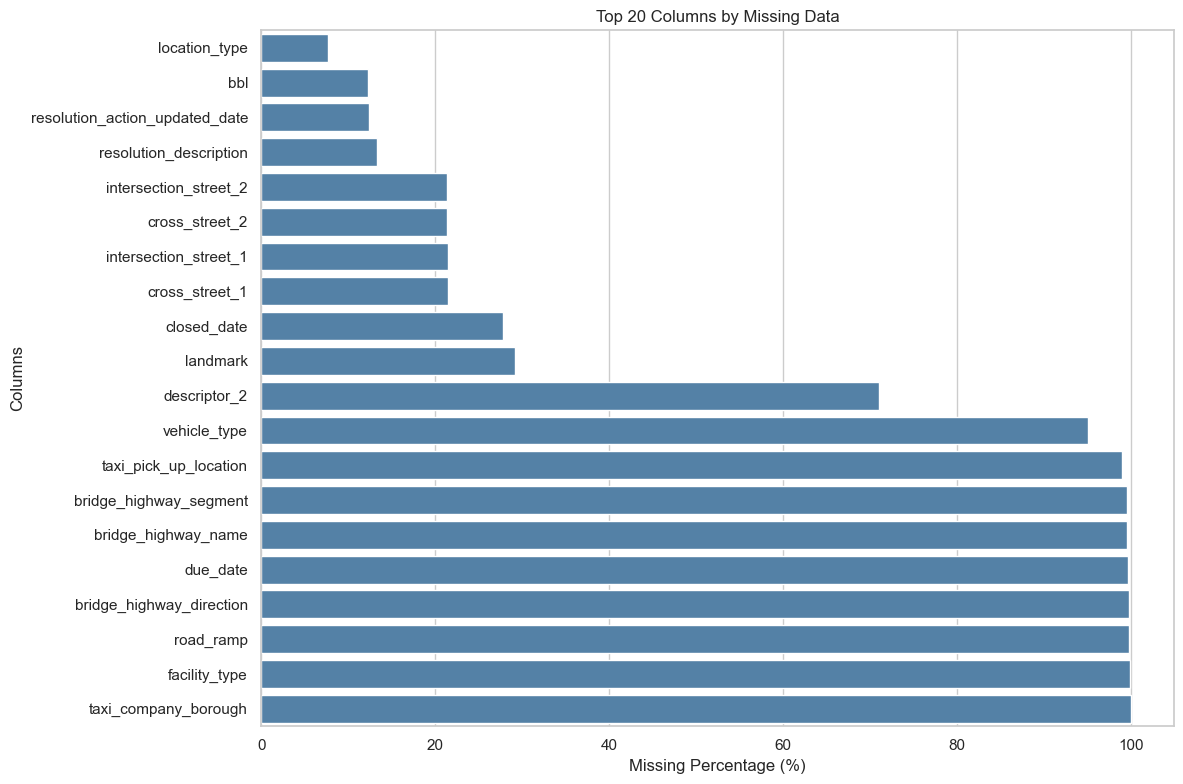

In [8]:
plt.figure(figsize=(12,8))

missing_plot = missing_df[missing_df["Missing Percentage"] > 0].tail(20)

sns.barplot(data = missing_plot ,
            x = "Missing Percentage", 
            y = missing_plot.index,
           color= 'steelblue')

plt.title("Top 20 Columns by Missing Data")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Columns")
# plt.xticks(rotation = 90)
plt.tight_layout()

plt.show()

### 3. Check Duplicates Records:

In [9]:
duplicates = df.duplicated().sum()
print(f'Number of Dublicated rows: {duplicates}')

Number of Dublicated rows: 0


### 4. Select Important Columns:

#### Selecting Relevant Features

The original dataset contains many columns.

we will focus on variables that provide useful information about:
- Time
- Complaint category
- Agency
- Geography
- Location

We will remove identifiers and highly detailed address fields that are not necessary for the main analysis.

#### Geographic information

We specifically keep:
- `incident_zip`
- `latitude`
- `longitude`
- `borough`
- `location`

In [10]:
selected_columns = [
    "unique_key",
    "created_date",
    "closed_date",
    "agency",
    "agency_name",
    "complaint_type",
    "descriptor",
    "location_type",
    "incident_zip",
    "city",
    "borough",
    "latitude",
    "longitude",
    "location",
    "status",
    "open_data_channel_type",
    "resolution_description"
]

df = df[selected_columns].copy()

df.shape

(100000, 17)

##### Business insight

Reducing the dataset to relevant variables simplifies the analysis and removes highly detailed fields that are not required for the current business questions. This makes the dataset easier to interpret and reduces unnecessary complexity for future machine learning models.

### 5. Data Type Conversion:

In [11]:
pd.DataFrame({
    "Dtypes" : df.dtypes,
}).T

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,city,borough,latitude,longitude,location,status,open_data_channel_type,resolution_description
Dtypes,int64,object,object,object,object,object,object,object,float64,object,object,float64,float64,object,object,object,object


In [12]:
# convert date columns to date_time
date_columns = ['created_date','closed_date']
df[date_columns] = df[date_columns].apply(pd.to_datetime)

# convert `incident_zip` to string
df['incident_zip'] = df['incident_zip'].astype('float')

### 6. Check Dattypes:

In [13]:
pd.DataFrame({
    "Dtypes" : df.dtypes,
}).T

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,city,borough,latitude,longitude,location,status,open_data_channel_type,resolution_description
Dtypes,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object,object,float64,float64,object,object,object,object


#### Business insight

Converting dates to datetime enables operational analysis based on time, such as identifying periods of high demand, peak hours, weekday patterns, and service resolution times.

### 7. Geographic Data Cleaning:

The dataset contains geographic columns:

- `Latitude`
- `Longitude`
- `Incident_zip` (Zip code)
- `Borough`
- `Location`

Latitude and longitude allow us to analyze the distribution of service requests.

After research I got that Valid NYC coordinates should approximately fall within:
- Latitude: 40–41
- Longitude: -75– -73

Because invalid coordinates can negatively affect analysis and machine learning models, we will remove records with invalid or missing geographic coordinates when performing geographic analysis.

In [14]:
geographic_invalid = (
    df['latitude'].isna() |
    df['longitude'].isna() | 
    (df['latitude'] < 40) |
    (df['latitude'] > 41) | 
    (df['longitude'] < -75) |
    (df['longitude'] > -73)
)

print(f'Invalid geographic records: {geographic_invalid.sum()}')

Invalid geographic records: 1871


Missing coordinates don't necessarily mean the service request itself is invalid so we can't delete these records .

In [15]:
df['has_valid_location'] = (
    df['latitude'].between(40,41) & 
    df['longitude'].between(-75,-73)
).astype(int)

df["has_valid_location"].value_counts()

has_valid_location
1    98129
0     1871
Name: count, dtype: int64

In [16]:
(df["has_valid_location"].sum()/len(df["has_valid_location"]) ) *100

np.float64(98.129)

#### Business insight

Approximately 98% of requests contain valid geographic coordinates, meaning the dataset provides strong coverage for spatial analysis. The invalid/missing coordinates should not automatically result in deleting the service requests because the request itself may still contain valuable complaint and operational information.

In [17]:
df["incident_zip"].values

array([11412., 10472., 11221., ..., 11101., 11213., 11101.],
      shape=(100000,))

In [18]:
df["incident_zip"] = df["incident_zip"].astype('Int64').astype("string")
df["incident_zip"].value_counts().head(15)

incident_zip
11226    1775
10453    1529
10452    1453
10457    1347
10458    1321
11201    1289
10467    1235
10456    1214
11385    1213
11207    1194
11222    1185
11221    1165
11208    1149
11368    1105
10468    1105
Name: count, dtype: Int64

### 8. Handle Missing Values:

For categorical variables, we will replace missing values with `"Unknown"`.

For numerical geographic variables, we will use median imputation .

For date columns, invalid dates will remain as `NaT` (Not a Time) .

In [19]:
categorical_columns = [
    "agency",
    "agency_name",
    "complaint_type",
    "descriptor",
    "location_type",
    "city",
    "borough",
    "status",
    "open_data_channel_type",
    "resolution_description"
]

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

In [20]:
# Check the null values in categorical columns
for col in categorical_columns:
    print(f'{col} --> {df[col].isna().sum()}')

agency --> 0
agency_name --> 0
complaint_type --> 0
descriptor --> 0
location_type --> 0
city --> 0
borough --> 0
status --> 0
open_data_channel_type --> 0
resolution_description --> 0


## Part 4: Feature Engineering

### 1. Time Feature

In [21]:
df['created_date'].head()

0   2026-08-31 01:59:39
1   2026-08-31 01:50:52
2   2026-08-31 01:50:48
3   2026-08-31 01:50:26
4   2026-08-31 01:50:21
Name: created_date, dtype: datetime64[ns]

In [22]:
df["created_year"] = df['created_date'].dt.year
df["created_month"] = df["created_date"].dt.month
df["created_day"] = df["created_date"].dt.day
df["created_hour"] = df["created_date"].dt.hour
df["created_quarter"] = df["created_date"].dt.quarter

### 2. Weekend Feature:

In [23]:
"""
  ***  Day of Week ***
monday -> 0
Tuesday -> 1
Wednesday -> 2
Thursday -> 3
Friday -> 4
Saturday -> 5
Sunday -> 6

"""

df["created_weekday"] = df["created_date"].dt.day_name()
df["created_dayofweek"] = df["created_date"].dt.dayofweek

df["is_weekend"] = (df["created_dayofweek"] >= 5).astype(int)

### 3. Season Feature:

In [24]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['created_month'].apply(get_season)

In [25]:
time_cols = [
    'created_year',
    'created_month',
    'created_day',
    'created_hour',
    'created_weekday',
    'created_dayofweek',
    'created_quarter', 
    'season'
]
df[time_cols].head()

,created_year,created_month,created_day,created_hour,created_weekday,created_dayofweek,created_quarter,season
0,2026,8,31,1,Monday,0,3,Summer
1,2026,8,31,1,Monday,0,3,Summer
2,2026,8,31,1,Monday,0,3,Summer
3,2026,8,31,1,Monday,0,3,Summer
4,2026,8,31,1,Monday,0,3,Summer


### 4. Request Duration In Days:

In [26]:
df["request_duration_days"] = (
    df["closed_date"] - df["created_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [27]:
duration_limit = df["request_duration_days"].quantile(0.99)

duration_eda = df[
    df["request_duration_days"] <= duration_limit
].copy()

In [28]:
df["request_duration_days"].describe()

count    72185.000000
mean         0.536894
std          1.136837
min         -2.000694
25%          0.024838
50%          0.078299
75%          0.350150
max          9.014838
Name: request_duration_days, dtype: float64

In [29]:
df.loc[df["request_duration_days"] < 0, "request_duration_days"] = np.nan

In [30]:
df["request_duration_days"].describe()

count    72080.000000
mean         0.537760
std          1.137368
min          0.000000
25%          0.024988
50%          0.078478
75%          0.351852
max          9.014838
Name: request_duration_days, dtype: float64

#### Business insight
The median being much lower than the mean suggests that:

Most requests are resolved relatively quickly, while a smaller number of requests remain open considerably longer and increase the average resolution time. This indicates that operational performance is likely affected by a smaller group of complex or delayed requests.

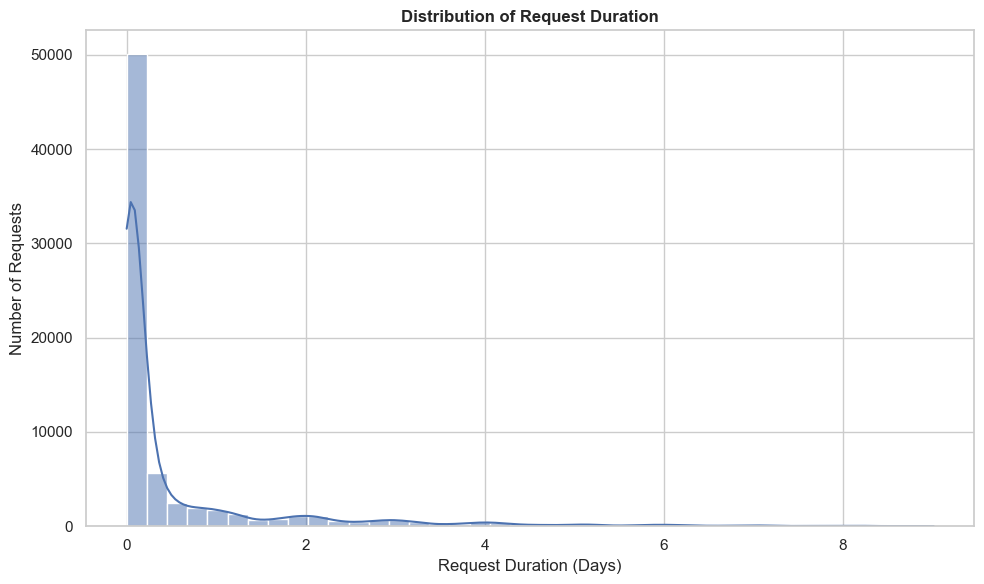

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["request_duration_days"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Request Duration", fontweight = 'bold')
plt.xlabel("Request Duration (Days)")
plt.ylabel("Number of Requests")

plt.tight_layout()

plt.savefig('Images/Request_Duration_Distribution.jpg')
plt.show()

#### Business insight

The resolution-time distribution is strongly concentrated toward shorter durations, while a smaller number of requests take significantly longer to close. This indicates that the city generally resolves many requests quickly, but there is a long tail of cases that may require additional resources or investigation.

#### Business action

Management should investigate the characteristics of long-duration requests to identify which agencies, complaint types, locations, or request categories are responsible for the delays.

### 5. Identify Numerical and Categorical Features:

In [32]:
numeric_features = [
    "latitude",
    "longitude",
    "created_year",
    "created_month",
    "created_hour",
    "created_dayofweek",
    "created_quarter",
    "is_weekend",
    "has_valid_location"
]

categorical_features = [
    "incident_zip",
    "borough",
    "agency",
    "complaint_type",
    "location_type",
    "open_data_channel_type",
    "season"
]

### 6. Data Preprocessing

Machine learning algorithms generally require numerical input.

#### Numerical features
use:
**StandardScaler**

#### Categorical features
use:
**OneHotEncoder**

In [33]:
df[categorical_features] = (
    df[categorical_features]
    .astype("object")
    .fillna("Unknown")
) 

df[numeric_features] = (
    df[numeric_features]
    .apply(pd.to_numeric, errors="coerce")
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown= 'ignore'), categorical_features)
])

df_processed = preprocessor.fit_transform(df)

feature_names = preprocessor.get_feature_names_out()

df_processed = pd.DataFrame(
    df_processed.toarray(),
    columns=feature_names,
    index=df.index
)

df_processed.head()

,num__latitude,num__longitude,num__created_year,num__created_month,num__created_hour,num__created_dayofweek,num__created_quarter,num__is_weekend,num__has_valid_location,cat__incident_zip_10000,...,cat__location_type_Vacant Lot/Property,cat__location_type_Vehicle Lane,cat__location_type_Waterway,cat__location_type_Within Building,cat__location_type_Yard,cat__open_data_channel_type_MOBILE,cat__open_data_channel_type_ONLINE,cat__open_data_channel_type_PHONE,cat__open_data_channel_type_UNKNOWN,cat__season_Summer
0,-0.444238,2.165957,0.0,0.0,-1.949173,-1.699591,0.0,-0.816258,0.138082,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.131482,0.605078,0.0,0.0,-1.949173,-1.699591,0.0,-0.816258,0.138082,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-0.449466,0.069893,0.0,0.0,-1.949173,-1.699591,0.0,-0.816258,0.138082,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.917678,-0.411821,0.0,0.0,-1.949173,-1.699591,0.0,-0.816258,0.138082,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.411350,1.185296,0.0,0.0,-1.949173,-1.699591,0.0,-0.816258,0.138082,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [34]:
df_combined = pd.concat([df,df_processed],axis = 1)
df_combined.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,city,...,cat__location_type_Vacant Lot/Property,cat__location_type_Vehicle Lane,cat__location_type_Waterway,cat__location_type_Within Building,cat__location_type_Yard,cat__open_data_channel_type_MOBILE,cat__open_data_channel_type_ONLINE,cat__open_data_channel_type_PHONE,cat__open_data_channel_type_UNKNOWN,cat__season_Summer
0,70248760,2026-08-31 01:59:39,NaT,DOT,Department of Transportation,Street Condition,Pothole,Unknown,11412,QUEENS,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,70243572,2026-08-31 01:50:52,NaT,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10472,BRONX,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,70239573,2026-08-31 01:50:48,NaT,DOHMH,Department of Health and Mental Hygiene,Smoking or Vaping,Allowed in Smoke Free Area,Residential Building,11221,BROOKLYN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,70249101,2026-08-31 01:50:26,NaT,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,11226,BROOKLYN,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,70248458,2026-08-31 01:50:21,NaT,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,11354,Unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


#### Business insight

The preprocessing converts numerical and categorical information into a machine-learning-ready format. Numerical variables are standardized, while categorical variables are converted into numerical indicator features.

## Part 5: Exploratory Data Analysis (EDA) 

### 1. Most Common Complaint Types

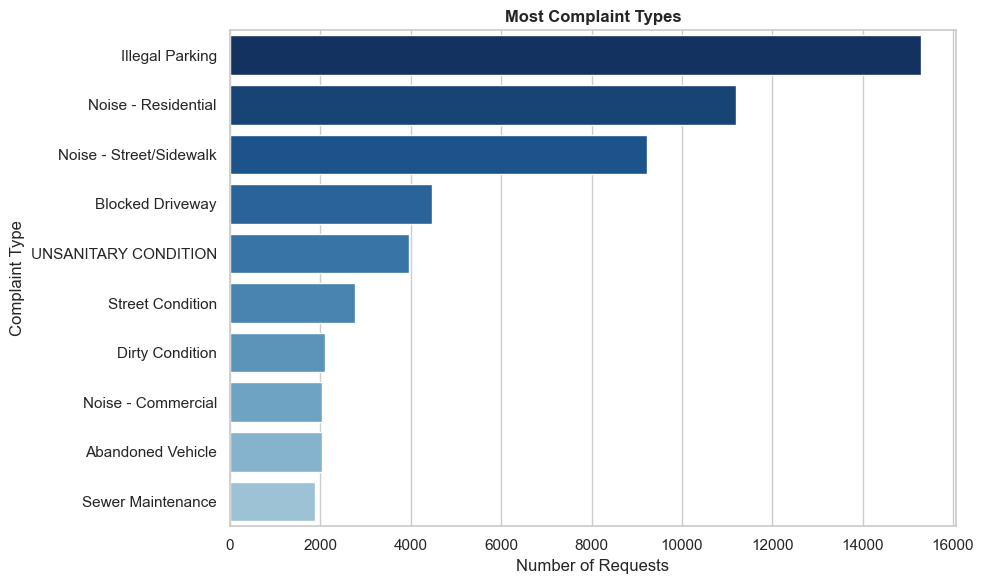

In [35]:
top_complaints = df['complaint_type'].value_counts().head(10)

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(top_complaints))
))

plt.figure(figsize=(10,6))

sns.barplot(x= top_complaints.values,
            y= top_complaints.index ,
           palette= colors
           )

plt.title('Most Complaint Types', fontweight = 'bold',)
plt.xlabel("Number of Requests")
plt.ylabel("Complaint Type")

# plt.xticks(rotation = 45,  ha='right')
plt.tight_layout()

plt.savefig('Images/Most_Complaint_Types.jpg')
plt.show()

#### Business insight

Illegal parking is the largest source of 311 requests in the analyzed sample, indicating that parking-related issues represent a significant demand on city services. This suggests that parking enforcement and prevention could have a meaningful impact on reducing service-request volume.

#### Business action

The city could:

Identify illegal-parking hotspots , Increase enforcement in high-demand areas

### 2. Top Agencies:

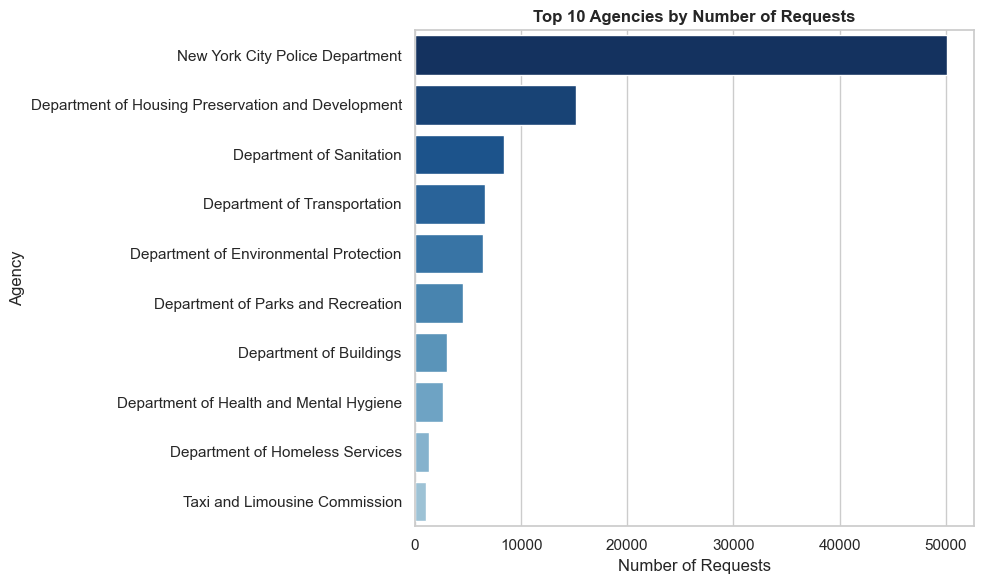

In [36]:
top_agencies = df["agency_name"].value_counts().head(10)

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(top_complaints))
))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_agencies.values,
    y=top_agencies.index,
    palette=colors
)

plt.title("Top 10 Agencies by Number of Requests", fontweight = 'bold')
plt.xlabel("Number of Requests")
plt.ylabel("Agency")

plt.tight_layout()

plt.savefig('Images/Top_Agencies.jpg')
plt.show()

#### Business insight

The NYPD accounts for high of the analyzed service requests, This concentration suggests that NYPD-related service categories may have a significant impact on overall demand and resource requirements.

### 3. Borough Analysis:

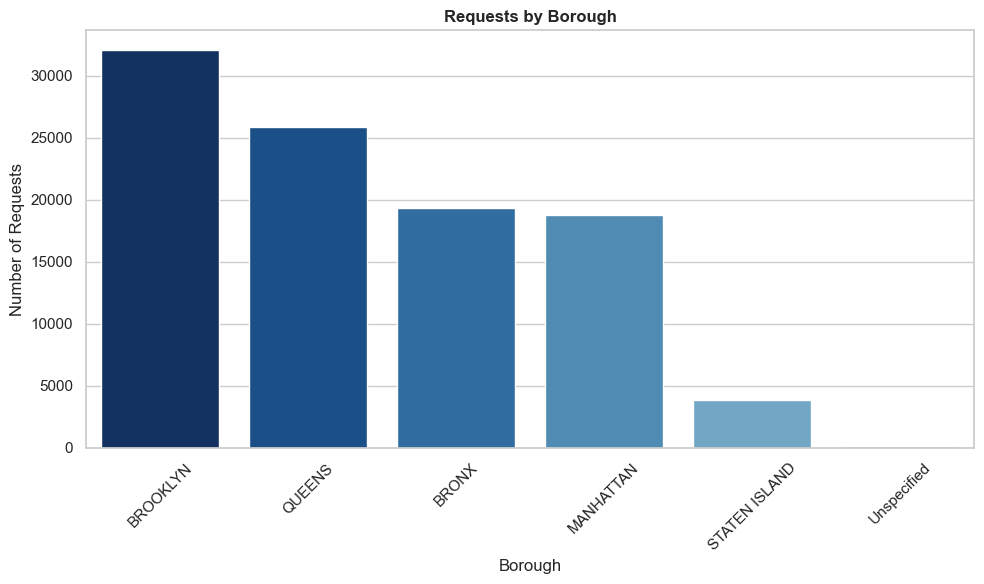

In [37]:
borough_counts = df["borough"].value_counts()

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(borough_counts))
))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=borough_counts.index,
    y=borough_counts.values,
    palette= colors
)

plt.title("Requests by Borough", fontweight = 'bold')
plt.xlabel("Borough")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Images/Borough_Analysis.jpg')
plt.show()

#### Business insight

Brooklyn has the highest number of service requests in the analyzed sample. This indicates greater demand for 311 services in the borough.

### 4. Location Type Analysis:

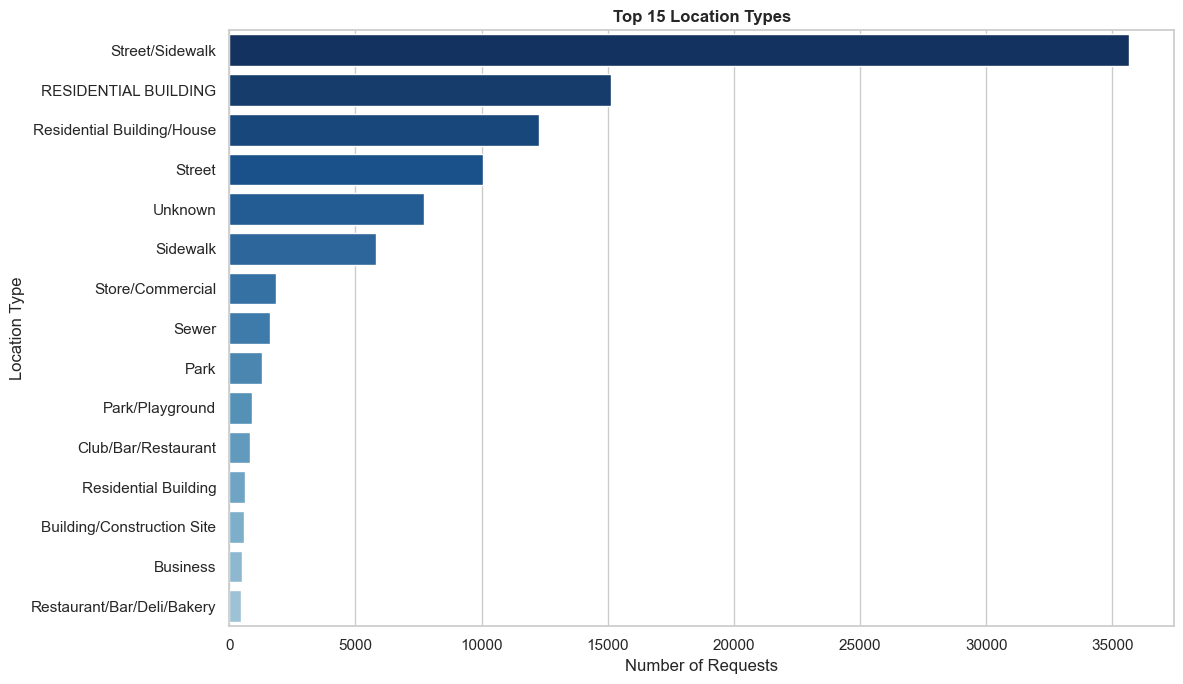

In [38]:
location_counts = df["location_type"].value_counts().head(15)

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(location_counts))
))

plt.figure(figsize=(12, 7))

sns.barplot(
    x=location_counts.values,
    y=location_counts.index,
    palette= colors
)

plt.title("Top 15 Location Types" , fontweight = 'bold')
plt.xlabel("Number of Requests")
plt.ylabel("Location Type")

plt.tight_layout()

plt.savefig('Images/Location_Type_Analysis.jpg')
plt.show()

#### Business insight

Street and sidewalk locations generate the largest share of service requests, highlighting public infrastructure and public-space issues as an important area of citizen demand.

### 5. Latitude / Longitude Scatter Plot:

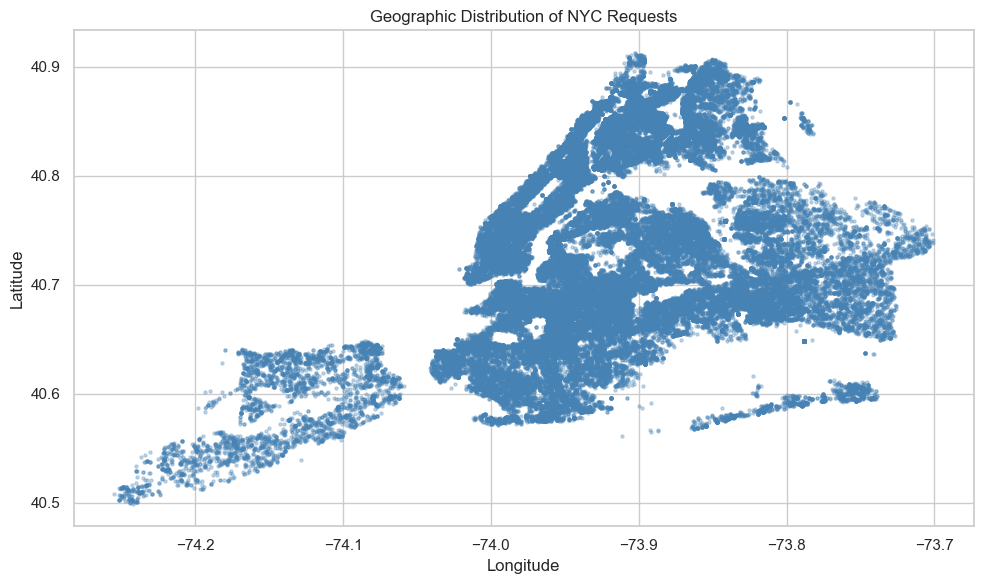

In [39]:
geo_df = df[
    df["has_valid_location"] == 1
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    s=5,
    alpha=0.3,
    c = 'steelblue'
)

plt.title("Geographic Distribution of NYC Requests")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig('Images/Latitude_Longitude.jpg')
plt.show()

#### Business insight

The geographic visualization illustrate that 311 requests are spatially distributed across NYC rather than being concentrated in a single location.

### 6.Geographic Distribution by Borough:

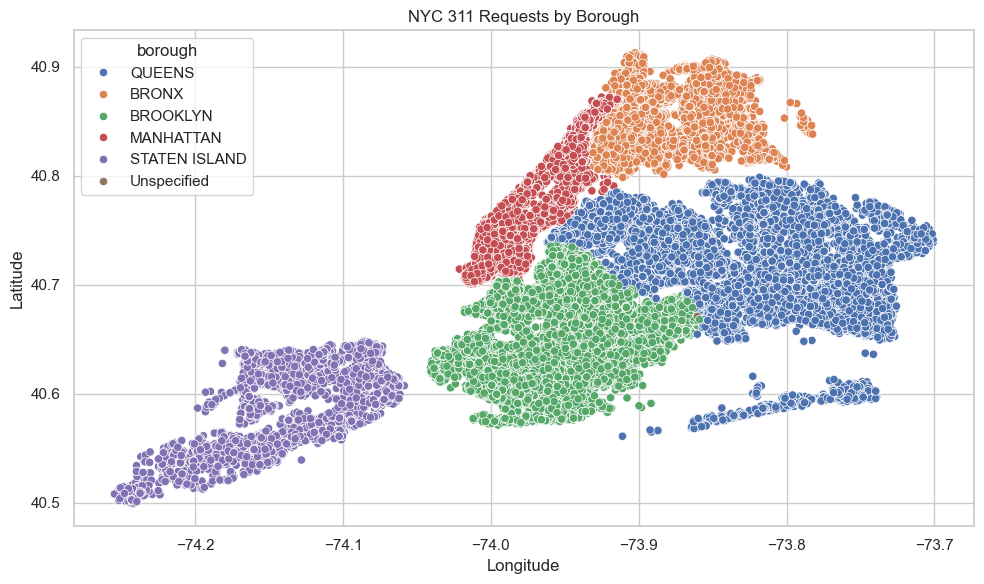

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=geo_df,
    x="longitude",
    y="latitude",
    hue="borough",
)

plt.title("NYC 311 Requests by Borough")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig('Images/Geographic_Distribution.jpg')
plt.show()

#### Business insight

The geographic distribution by borough allows city planners to compare the spatial concentration of service requests across different areas. This can reveal whether high request volumes are geographically clustered and help identify areas that may require targeted intervention.

### 7. Zip Code Analysis:

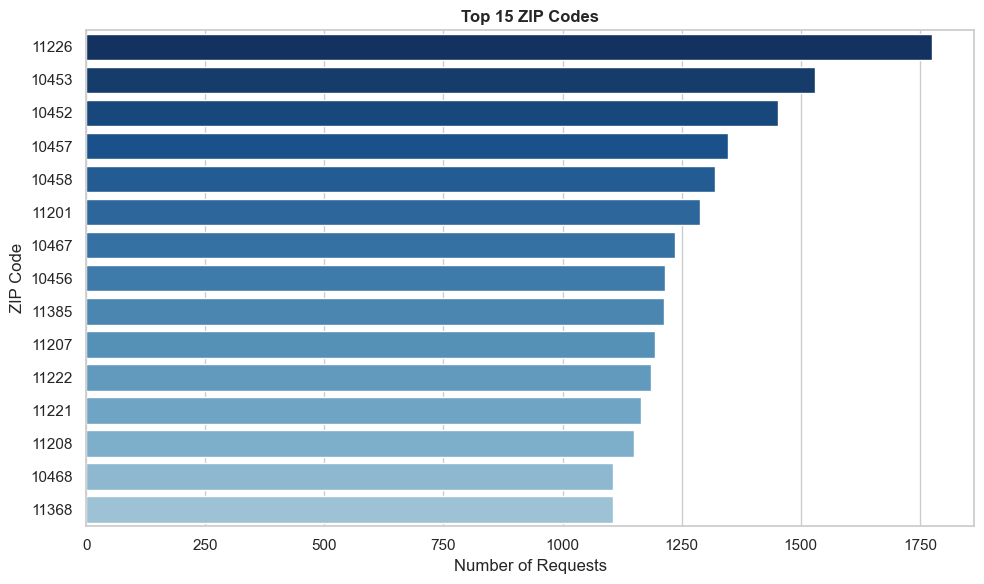

In [41]:
top_zipcodes = df["incident_zip"].value_counts().head(15)

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(top_zipcodes))
))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_zipcodes.values,
    y=top_zipcodes.index,
    palette= colors
)

plt.title("Top 15 ZIP Codes" , fontweight = 'bold')
plt.xlabel("Number of Requests")
plt.ylabel("ZIP Code")

plt.tight_layout()

plt.savefig('Images/Zip_code_Analysis.jpg')
plt.show()

#### Business insight

Service requests are concentrated in specific ZIP codes, with 11226 having the highest request volume in the analyzed sample.

### 8. Requests by Day:

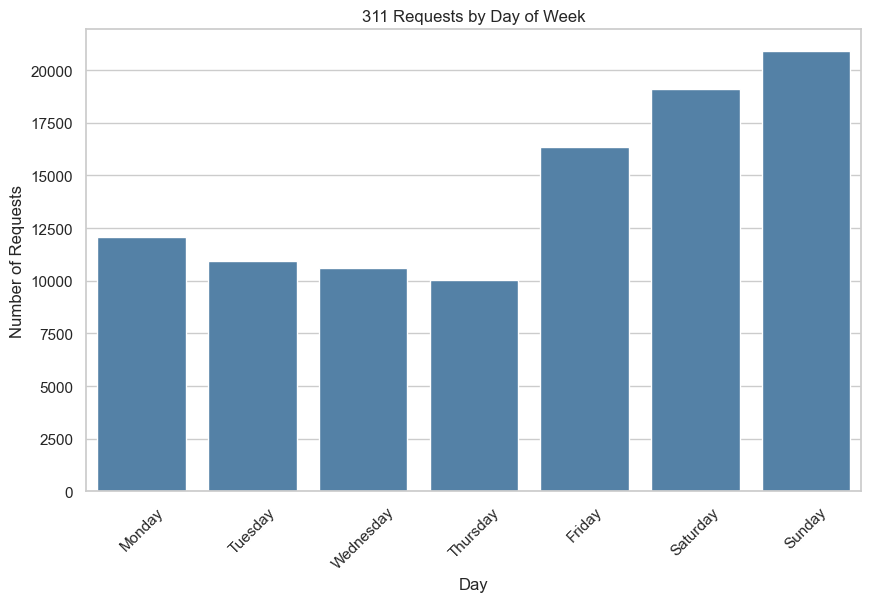

In [42]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_counts = (
    df["created_weekday"]
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=weekday_counts.index,
    y=weekday_counts.values,
    color= 'steelblue'
)

plt.title("311 Requests by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Requests")

plt.xticks(rotation=45)

plt.show()

#### Business insight

Sunday has the highest request volume, suggesting that agencies may need additional capacity at this weekday . 

## Part 6: Advanced Exploratory Data Analysis (EDA)

### 1. Complaint Type × Borough

In [43]:
top_complaints = (
    df["complaint_type"]
    .value_counts()
    .head(15)
    .index
)

complaint_borough = (
    df[df["complaint_type"].isin(top_complaints)]
    .groupby(["complaint_type", "borough"])
    .size()
    .unstack(fill_value=0)
)

complaint_borough.head()

borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified
complaint_type,,,,,,
Abandoned Vehicle,232,754,72,809,163,0
Blocked Driveway,771,1577,92,1896,134,1
Dirty Condition,318,739,339,592,115,0
Illegal Parking,2362,5908,1737,4830,457,0
Noise,143,575,560,282,64,0


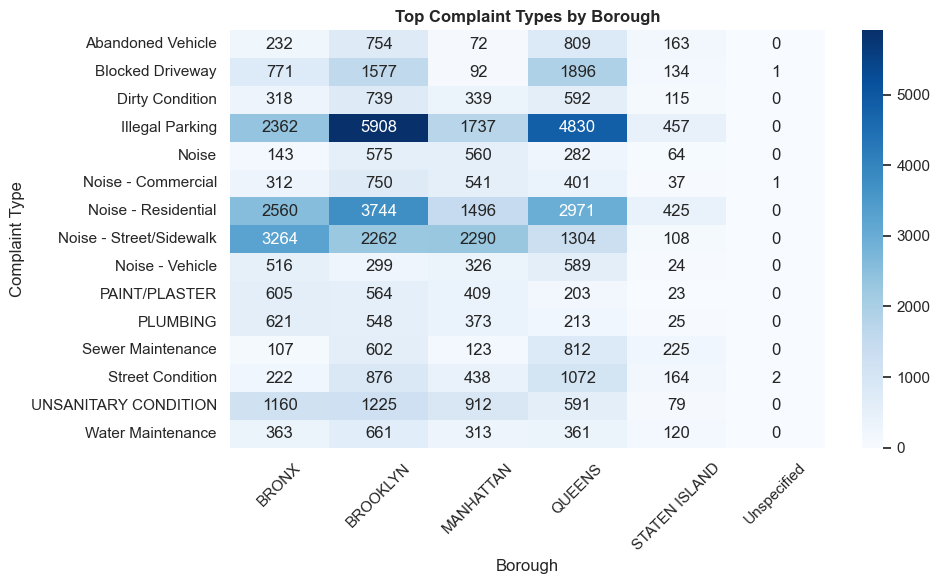

In [44]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    complaint_borough,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Top Complaint Types by Borough", fontweight="bold")
plt.xlabel("Borough")
plt.ylabel("Complaint Type")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Images/Top_Complaint_Types _Borough.jpg')
plt.show()

#### Business insight

Complaint patterns vary significantly across boroughs. Illegal Parking is especially concentrated in Brooklyn and Queens, while Noise – Street/Sidewalk complaints are highest in the Bronx and Manhattan.

### 2. Agency × Average Resolution Time

In [45]:
agency_duration = (
    duration_eda
    .groupby("agency_name")
    .agg(
        average_duration=("request_duration_days", "mean"),
        median_duration=("request_duration_days", "median"),
        request_count=("request_duration_days", "count")
    )
)

agency_duration = agency_duration[
    agency_duration["request_count"] >= 100
].sort_values(
    "average_duration",
    ascending=False
)

agency_duration.head()

,average_duration,median_duration,request_count
agency_name,,,
Department of Housing Preservation and Development,2.640537,2.422141,3416
Department of Health and Mental Hygiene,1.988315,1.838704,532
Taxi and Limousine Commission,1.599010,1.538183,102
Department of Sanitation,1.485688,1.193889,5741
Department of Consumer and Worker Protection,1.282281,0.994485,144


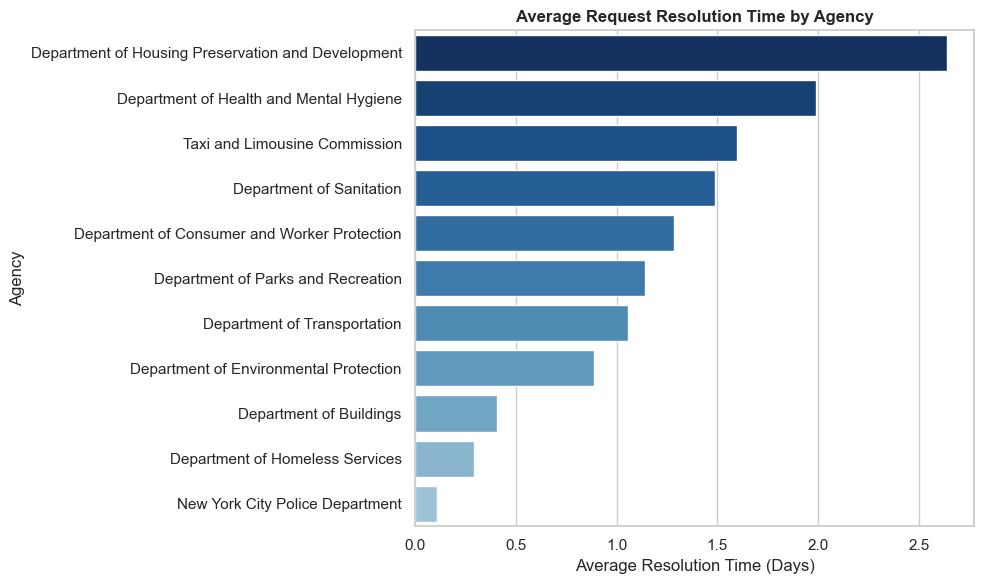

In [46]:
top_agencies_duration = agency_duration.head(15)

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(top_agencies_duration))
))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_agencies_duration,
    x="average_duration",
    y=top_agencies_duration.index,
    palette= colors
)

plt.title( "Average Request Resolution Time by Agency", fontweight="bold")

plt.xlabel("Average Resolution Time (Days)")
plt.ylabel("Agency")

plt.tight_layout()

plt.savefig('Images/Request_Resolution_Time_Agency.jpg')
plt.show()

#### Business Insight

HPD has the longest average resolution time, suggesting a need to investigate workload and operational delays.

### 3. Complaint Type × Resolution Time

In [47]:
complaint_duration = (
    duration_eda
    .groupby("complaint_type")
    .agg(
        average_duration=("request_duration_days", "mean"),
        median_duration=("request_duration_days", "median"),
        request_count=("request_duration_days", "count")
    )
)

complaint_duration = complaint_duration[
    complaint_duration["request_count"] >= 100
].sort_values(
    "average_duration",
    ascending=False
)

complaint_duration.head()

,average_duration,median_duration,request_count
complaint_type,,,
UNSANITARY CONDITION,3.261775,3.275972,557
FLOORING/STAIRS,3.233327,3.256065,105
DOOR/WINDOW,3.130981,3.240822,176
WATER LEAK,3.125543,3.198727,275
PAINT/PLASTER,2.911330,2.997407,429


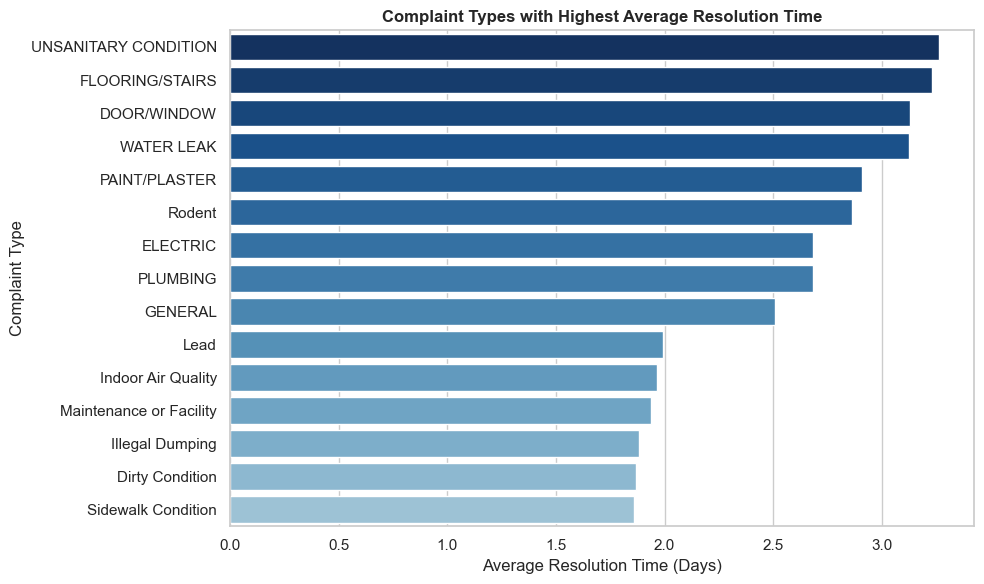

In [48]:
top_slow_complaints = complaint_duration.head(15)

colors = list(plt.cm.Blues(
    np.linspace(1, 0.4, len(top_slow_complaints))
))


plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_slow_complaints,
    x="average_duration",
    y=top_slow_complaints.index, 
    palette= colors
)

plt.title("Complaint Types with Highest Average Resolution Time",fontweight="bold")
plt.xlabel("Average Resolution Time (Days)")
plt.ylabel("Complaint Type")

plt.tight_layout()

plt.savefig('Images/Complaint_Types_Resolution_Time.jpg')
plt.show()

#### Business Insight

Housing-related complaints take longer to resolve, indicating higher complexity and resource requirements.

### 4. Weekend vs Weekday × Complaint Type

In [49]:
df["day_type"] = np.where(
    df["is_weekend"] == 1,
    "Weekend",
    "Weekday"
)

weekend_percentage = pd.crosstab(
    df["complaint_type"],
    df["day_type"],
    normalize="index"
) * 100

weekend_percentage = weekend_percentage.loc[
    top_complaints
]

weekend_percentage.head()

day_type,Weekday,Weekend
complaint_type,,
Illegal Parking,58.173140,41.826860
Noise - Residential,43.247588,56.752412
Noise - Street/Sidewalk,37.006935,62.993065
Blocked Driveway,57.101320,42.898680
UNSANITARY CONDITION,75.598689,24.401311


<Figure size 1000x600 with 0 Axes>

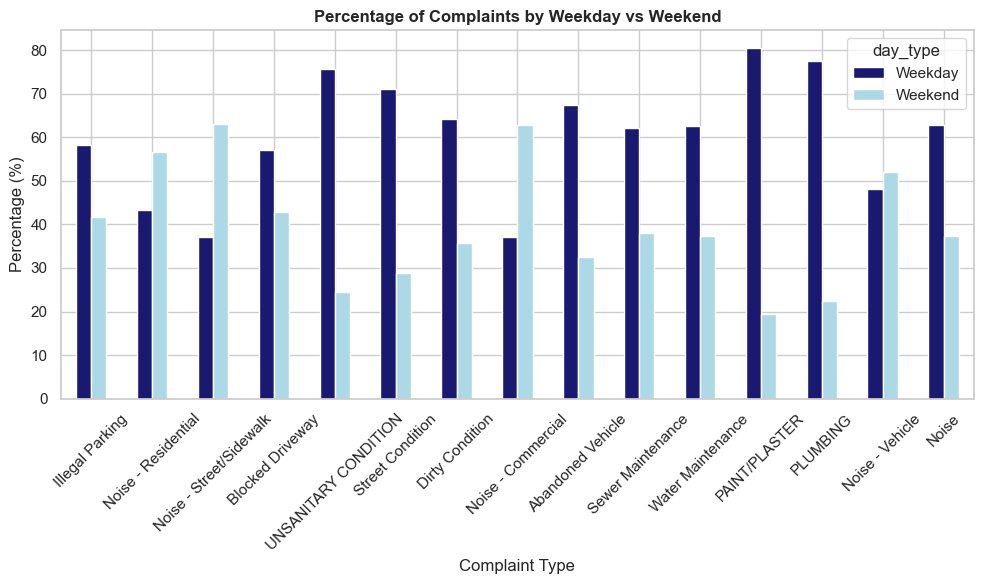

In [50]:
plt.figure(figsize=(10, 6))

weekend_percentage.plot(
    kind="bar",
    figsize=(10, 6),
    # color = ['navy','lightblue']
    color = ['midnightblue','lightblue']
)

plt.title("Percentage of Complaints by Weekday vs Weekend",fontweight="bold")
plt.xlabel("Complaint Type")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Images/Complaints_Weekday_Weekend.jpg')
plt.show()

#### Business Insight

Noise complaints are relatively more common on weekends, suggesting a need for stronger weekend response coverage.

## Part 7: Final Conclusion:

### Key Findings

**1. Complaint demand is concentrated in a small number of categories.**
Illegal Parking is the most common complaint type in the analyzed sample, with 15,294 requests. This indicates that parking-related issues represent a major source of demand for city services and may be an important area for targeted enforcement and prevention.

**2. Service demand is concentrated across specific agencies.**
The NYPD handled approximately half of the analyzed requests, showing that a relatively small number of agencies account for a large proportion of the overall 311 workload. This concentration can help management prioritize staffing and operational resources.

**3. Brooklyn has the highest request volume.**
Brooklyn accounts for the largest number of requests in the sample, with 32,035 records. However, high request volume should not automatically be interpreted as poorer conditions because population size and reporting behavior can also affect the number of requests.

**4. Public spaces are a major source of complaints.**
Street/Sidewalk is the most common location type, suggesting that public infrastructure and public-space issues are an important component of citizen demand.

**5. Service requests show geographic concentration.**
The ZIP-code analysis identifies specific areas with substantially higher request volumes. These areas should be investigated further to determine which complaint types are responsible and whether the concentration is related to population, infrastructure, or other local factors.

**6. Most requests appear to be resolved quickly, but some take considerably longer.**
The median resolution duration is approximately 0.08 days, while the mean is approximately 0.54 days. The difference indicates a right-skewed distribution in which most requests are resolved relatively quickly, while a smaller number of cases take significantly longer.

**7. Geographic data is highly usable.**
Approximately 98.1% of records have valid geographic coordinates. Instead of deleting requests with missing coordinates, a `has_valid_location` feature was created so that the records can still be used for non-geographic analysis.

#### Business Recommendations

Based on these findings, NYC agencies could:

* Prioritize high-volume complaint categories such as illegal parking.
* Identify geographic hotspots and investigate the complaints driving those hotspots.
* Adjust staffing according to demand by hour, day, and season.
* Analyze long-duration requests to identify the agencies and complaint types associated with slower resolution.
* Compare request volume with population by ZIP code or borough before making resource-allocation decisions.

#### Overall Conclusion

The analysis shows that NYC 311 requests are not randomly distributed. They vary by **complaint type, agency, location, geography, and time**. Understanding these patterns can help city agencies move from reactive service delivery toward more proactive resource planning.